In [8]:
days_holding = "3"
top_percentile = "0.95"
bottom_percentile = "0.00"
days_momentum_score = "40"
days_momentum_gate = ""
min_volume = "1_000_000"

In [9]:
days_holding_P = int(days_holding)
top_percentile_P = float(top_percentile)
bottom_percentile_P = (
    float(bottom_percentile) if bottom_percentile != "None" else None
)
days_momentum_score_P = int(days_momentum_score)
days_momentum_gate_P = [int(n) for n in days_momentum_gate.split(",") if n != ""]
min_volume_P = int(min_volume)

print(f"""
days_holding: {days_holding_P}
days_momentum_score: {days_momentum_score_P}
days_momentum_gate: {days_momentum_gate_P}
min_volume: {min_volume_P}

top_percentile: {top_percentile_P}
bottom_percentile: {bottom_percentile_P}
""")


days_holding: 3
days_momentum_score: 40
days_momentum_gate: []
min_volume: 1000000

top_percentile: 0.95
bottom_percentile: 0.0



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 135/135 [00:00<00:00, 614.34it/s]


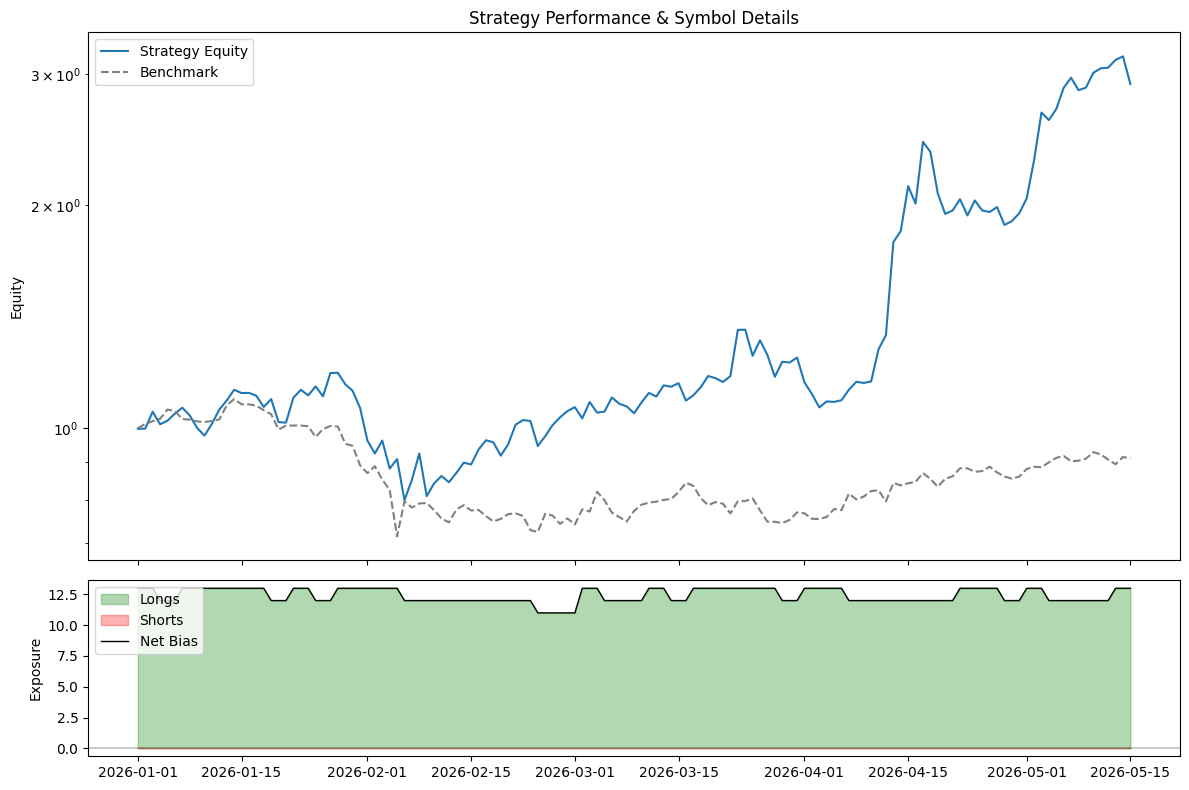

mfe: 0.7934863098691546 (None)


ann_return: 2.421287619268548 (-0.08273827451871545)


mfe_std: 2.2142658629153003 (None)


sharpe: 2.576321943300738 (-0.19337991627693024)


cagr: 17.50701951483971 (-0.2246747747487028)


...

win_rate: 0.6720257234726688 (None)


sortino: 5.52119819922632 (-0.3099691929089353)


mae: -0.10949727937342407 (None)


mae_std: 0.12229275061852066 (None)


maxdd: -0.32677377712792444 (-0.3472066262143424)


In [10]:
import datetime as dt
import polars as pl
import scrapbook as sb
import backtest as bt
import functools as fc
import operator

df = (
    pl.read_parquet("polarity/latest-data/*parquet")
    .rename(
        {
            "asset": "symbol",
            "price": "close",
        }
    )
    .with_columns(ts=pl.col("ts").dt.cast_time_unit("us"))
    .sort(["symbol", "ts"])
    .with_columns(**{
        f'mom{n}': pl.col("close").pct_change(n).over("symbol")
        for n in set([days_momentum_score_P, *days_momentum_gate_P])
    })
    .with_columns(
        rank=(
            pl.col(f"mom{days_momentum_score_P}").rank(method="ordinal").over("ts")
            / pl.col(f"mom{days_momentum_score_P}").count().over("ts")
        ),
        volume=pl.col('total_volume').rolling_mean(days_holding_P).over('symbol'),
    )
    .sort("ts")
    .filter(pl.col("ts").dt.year() >= 2026)
    .drop_nulls(['volume'])
)

class Alpha(bt.AlphaModel):
    def __init__(self, long_expr: pl.Expr, short_expr: pl.Expr):
        self.long_expr = long_expr
        self.short_expr = short_expr

    def __call__(self, df: pl.DataFrame) -> list[bt.Signal]:
        today = df["ts"].max()
        dfnow = df.filter(pl.col("ts") == today)
        l = dfnow.filter(self.long_expr)
        s = dfnow.filter(self.short_expr)

        return [
            bt.Signal(r['symbol'], True, r['rank'])
            for r in l.iter_rows(named=True)
        ] + [
            bt.Signal(r['symbol'], False, 1-r['rank'])
            for r in s.iter_rows(named=True)
        ]

if len(days_momentum_gate_P) > 0:
    long_gate_expr = fc.reduce(operator.or_, [pl.col(f'mom{n}') > 0 for n in days_momentum_gate_P]) & (pl.col('mkt') > -0.0)
    short_gate_expr = fc.reduce(operator.and_, [pl.col(f'mom{n}') < 0 for n in days_momentum_gate_P]) & (pl.col('mkt') < -0.15)
else:
    long_gate_expr = pl.lit(True)
    short_gate_expr = pl.lit(True)


test = bt.Backtest(
    df,
    alpha=Alpha(
        long_expr=(pl.col("rank") >= top_percentile_P) & long_gate_expr & (pl.col('volume') > min_volume_P),
        short_expr=(
            (pl.col("rank") <= bottom_percentile_P) & short_gate_expr & (pl.col('volume') > min_volume_P)
            if bottom_percentile_P is not None
            else pl.lit(False)
        ),
    ),
    benchmark="btc",
    period=days_holding_P,
    eager_rebalance=True,
)

test.run()
res = test.report(plot=True)

for col in set(res.columns) - {'year', 'src'}:
    s = res.filter(pl.col('src') == 'Strategy')
    b = res.filter(pl.col('src') == 'Benchmark')

    print(f"{col}: {s[col].mean()} ({b[col].mean()})")
    sb.glue(col,s[col].mean())

In [11]:
print(
    test.live(equity=10_000)
    .select(
        pl.col('entry_ts').dt.strftime('%Y-%m-%d'),
        pl.col('symbol').str.to_uppercase(),
        pl.lit(''),
        pl.col('entry_price'),
        pl.col('shares'),
        (pl.col('entry_price') * pl.col('shares')).alias('cost'),
    )
    .sort('symbol')
    .write_csv()
)

entry_ts,symbol,literal,entry_price,shares,cost
2026-05-15,B,"",0.46249078453983333,1663.234803686163,769.2307692307693
2026-05-15,GWEI,"",0.15826501305904375,4860.396839216721,769.2307692307693
2026-05-15,H,"",0.25027402641184127,3073.554136876165,769.2307692307693
2026-05-15,LAB,"",4.202230473478899,183.05297010374267,769.2307692307693
2026-05-15,LUNC,"",0.00007599039783074622,10122736.440255,769.2307692307692
2026-05-15,PENDLE,"",2.07,371.60906726124125,769.2307692307693
2026-05-15,RAVE,"",0.6552351000335368,1173.9767439067257,769.2307692307692
2026-05-15,SKYAI,"",0.36897040919365426,2084.803415297833,769.2307692307694
2026-05-15,TAG,"",0.0012537740929176701,613532.193379977,769.2307692307693
2026-05-15,UB,"",0.22915832821486046,3356.76549581708,769.2307692307693
2026-05-15,VVV,"",14.019609912347354,54.868200616144975,769.2307692307693
2026-05-15,ZEC,"",547.0379117057367,1.4061745132658279,769.2307692307693
2026-05-15,币安人生,"",0.42831788605045923,1795.9342681761084,769.2307692307693
